Implementing simple chatbot using LangGraph

In [23]:
from dotenv import load_dotenv
load_dotenv()

True

In [25]:
import os 
from typing_extensions import Annotated
from langgraph.graph import StateGraph,START,END

from typing import Annotated
from langgraph.graph.message import add_messages



In [13]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [24]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="deepseek-chat",openai_api_base="https://api.deepseek.com")
llm.invoke("HeY I am rahul and I like to play cricket")

AIMessage(content="Hey Rahul! That's awesome. Cricket is a fantastic sport. Do you prefer batting, bowling, or fielding the most?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 17, 'total_tokens': 43, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 17}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_058df29938_prod0820_fp8_kvcache_20260402', 'id': '1c16ddf8-1234-4ab8-82b9-7eaa52a74edb', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019de397-2390-7dd1-9ad0-de5584691822-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 26, 'total_tokens': 43, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}})

### We Will start With Creating Nodes

In [33]:
def superbot(state:State)->State:
    return {"messages":[llm.invoke(state['messages'])]}

In [36]:
graph=StateGraph(State)

graph.add_node("Superbot",superbot)

graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)

graph_builder=graph.compile()



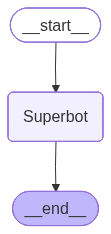

In [37]:
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [38]:
## Invocation

graph_builder.invoke({'messages':"Hi,My name is Rahul and I like butter naan"})

{'messages': [HumanMessage(content='Hi,My name is Rahul and I like butter naan', additional_kwargs={}, response_metadata={}, id='cd325354-fc4c-4bff-b5c5-eac1d8246dad'),
  AIMessage(content='Nice to meet you, Rahul! Butter naan is a fantastic choice—soft, fluffy, and that rich, buttery flavor is hard to beat. Pair it with a good dal makhani or paneer butter masala, and you’ve got a perfect meal.\n\nDo you like it with any specific curry or just on its own?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 16, 'total_tokens': 86, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 16}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_058df29938_prod0820_fp8_kvcache_20260402', 'id': '20690476-8a25-45de-9dd1-26875522be2b', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run-

#### Streaming The responses


In [41]:
for event in graph_builder.stream({"messages":"Hello my name is rahul man"}):
    print(event)

{'Superbot': {'messages': [AIMessage(content="Hello Rahul! It's nice to meet you. How can I help you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 12, 'total_tokens': 29, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 12}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_058df29938_prod0820_fp8_kvcache_20260402', 'id': '48dc9383-f806-4fd5-bb28-2ec2d4795103', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019de3b5-d2c0-74d0-8531-7fb21ced2d9c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 17, 'total_tokens': 29, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}})]}}


in the stream if we observe we are getting only the last one   or the last message (check for stream_mode="values" or "updates") if we didnt use this only human messages will return , but if we use this we get both ai message and human message [default is stream updates]